Case Study: License Plate Detection & Blurring using YOLOv8
--

Build an automated system using YOLOv8 to accurately detect vehicle license plates in images or video streams and blur them in real time, ensuring privacy preservation while maintaining the usefulness of the visual data for analysis and monitoring purposes.

Mount the Google Drive to download the zipped data to
local content folder, also set the output paths
--

In [ ]:
"""
## 1. Mount Google Drive & Load Data
Loading dataset from Google Drive folder.
"""

print("="*80)
print("📂 MOUNTING GOOGLE DRIVE")
print("="*80)

# Mount Google Drive (required for Colab)
from google.colab import drive
import os
from pathlib import Path

drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

# Set dataset path to Google Drive folder
DATASET_PATH = '/content/drive/MyDrive/LicensePlateDetection/Data'

print(f"\n📁 Dataset path: {DATASET_PATH}")
# For outputs, use Colab's local storage (faster)
notebook_dir = Path('/content')


# Define paths for train/val/test splits
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
VAL_PATH = os.path.join(DATASET_PATH, 'val')
TEST_PATH = os.path.join(DATASET_PATH, 'test')

# Define paths for labels (separate folder structure)
LABELS_PATH = os.path.join(DATASET_PATH, 'labels')
TRAIN_LABELS_PATH = os.path.join(LABELS_PATH, 'train')
VAL_LABELS_PATH = os.path.join(LABELS_PATH, 'val')
TEST_LABELS_PATH = os.path.join(LABELS_PATH, 'test')

# Create output directories in project folder
OUTPUT_DIR = str(notebook_dir / 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/training', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/inference', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/blurred', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/visualizations', exist_ok=True)

print(f"   Output: {OUTPUT_DIR}")

print(f"\n✅ All paths configured!")
print(f"     Test: {TEST_LABELS_PATH}")

print(f"   Images:")
print(f"     Train: {TRAIN_PATH}")
print(f"     Val: {VAL_PATH}")
print(f"     Test: {TEST_PATH}")

print(f"   Labels:")
print(f"     Train: {TRAIN_LABELS_PATH}")
print(f"     Val: {VAL_LABELS_PATH}")
print(f"     Test: {TEST_LABELS_PATH}")

Loading dataset from local folder...
Dataset path: c:\Projects\AI\Scaler\LicensePlateDetection\Data
   Output: c:\Projects\AI\Scaler\LicensePlateDetection\outputs

✅ All paths configured!
     Test: c:\Projects\AI\Scaler\LicensePlateDetection\Data\labels\test
   Images:
     Train: c:\Projects\AI\Scaler\LicensePlateDetection\Data\train
     Val: c:\Projects\AI\Scaler\LicensePlateDetection\Data\val
     Test: c:\Projects\AI\Scaler\LicensePlateDetection\Data\test
   Labels:
     Train: c:\Projects\AI\Scaler\LicensePlateDetection\Data\labels\train
     Val: c:\Projects\AI\Scaler\LicensePlateDetection\Data\labels\val
     Test: c:\Projects\AI\Scaler\LicensePlateDetection\Data\labels\test


Copy the data from Google Drive to local content folder
--

In [ ]:
# Copy from Drive to local
import shutil
print("📦 Copying dataset from Drive to local storage...")
shutil.copytree(
    '/content/drive/MyDrive/Colab Notebooks',
    '/content/Data'
)
print("✅ Copy complete!")


Mounted at /content/drive
📦 Copying dataset from Drive to local storage...
✅ Copy complete!


Unzip the data in local content folder
--

In [ ]:
from google.colab import files
import zipfile
import os

# Extract to /content/Data
zip_filename = '/content/Data/LicensePlateData.zip'
print("\n📦 Extracting files...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("✅ Extraction complete!")

# Verify extraction
if os.path.exists('/content/Data'):
    print("✅ Dataset ready at: /content/Data")
else:
    print("❌ Check extraction - expected /content/Data folder")


📦 Extracting files...
✅ Extraction complete!
✅ Dataset ready at: /content/Data


Define Paths for Data and Output folders
--

In [ ]:
import os
from pathlib import Path

# Set dataset path to Google Drive folder
# Update this path to match your Google Drive folder structure
DATASET_PATH = '/content/Data'

print(f"\n📁 Dataset path: {DATASET_PATH}")

notebook_dir = Path('/content')


# Define paths for train/val/test splits
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
VAL_PATH = os.path.join(DATASET_PATH, 'val')
TEST_PATH = os.path.join(DATASET_PATH, 'test')

# Define paths for labels (separate folder structure)
LABELS_PATH = os.path.join(DATASET_PATH, 'labels')
TRAIN_LABELS_PATH = os.path.join(LABELS_PATH, 'train')
VAL_LABELS_PATH = os.path.join(LABELS_PATH, 'val')
TEST_LABELS_PATH = os.path.join(LABELS_PATH, 'test')

# Create output directories in project folder
# drive_dir = Path('/content/drive/MyDrive/Colab Notebooks')
OUTPUT_DIR = str(notebook_dir / 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/training', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/inference', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/blurred', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/visualizations', exist_ok=True)

print(f"   Output: {OUTPUT_DIR}")

print(f"\n✅ All paths configured!")
print(f"     Test: {TEST_LABELS_PATH}")

print(f"   Images:")
print(f"     Train: {TRAIN_PATH}")
print(f"     Val: {VAL_PATH}")
print(f"     Test: {TEST_PATH}")

print(f"   Labels:")
print(f"     Train: {TRAIN_LABELS_PATH}")
print(f"     Val: {VAL_LABELS_PATH}")
print(f"     Test: {TEST_LABELS_PATH}")


📁 Dataset path: /content/Data
   Output: /content/outputs

✅ All paths configured!
     Test: /content/Data/labels/test
   Images:
     Train: /content/Data/train
     Val: /content/Data/val
     Test: /content/Data/test
   Labels:
     Train: /content/Data/labels/train
     Val: /content/Data/labels/val
     Test: /content/Data/labels/test


Dataset Verification - Check images and labels in separate folders
--

In [ ]:
import os
from pathlib import Path
import shutil

def verify_dataset_structure(image_path, label_path, split_name):
    """Verify dataset structure with separate image and label folders"""
    print(f"\n{'='*80}")
    print(f"🔍 Verifying {split_name} Dataset")
    print(f"{'='*80}")

    if not os.path.exists(image_path):
        print(f"❌ Image path does not exist: {image_path}")
        return 0

    if not os.path.exists(label_path):
        print(f"❌ Label path does not exist: {label_path}")
        return 0

    # Find all images
    image_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    image_files = [f for f in Path(image_path).iterdir() if f.suffix in image_extensions]

    # Find all labels
    label_files = [f for f in Path(label_path).iterdir() if f.suffix == '.txt']

    print(f"\n📊 File counts:")
    print(f"   Images in {os.path.basename(image_path)}/: {len(image_files)}")
    print(f"   Labels in labels/{os.path.basename(label_path)}/: {len(label_files)}")

    # Check image-label pairs
    images_with_labels = []
    images_without_labels = []

    for img in image_files:
        label_file = Path(label_path) / img.with_suffix('.txt').name
        if label_file.exists():
            images_with_labels.append(img.name)
        else:
            images_without_labels.append(img.name)

    print(f"\n✅ Images WITH matching labels: {len(images_with_labels)}")
    print(f"❌ Images WITHOUT matching labels: {len(images_without_labels)}")

    if images_without_labels and len(images_without_labels) <= 5:
        print(f"\n⚠️  Images missing labels:")
        for fname in images_without_labels:
            print(f"   - {fname}")
    elif images_without_labels:
        print(f"\n⚠️  First 5 images missing labels:")
        for fname in images_without_labels[:5]:
            print(f"   - {fname}")

    # Check label file format
    if len(images_with_labels) > 0:
        print(f"\n📝 Checking label file format...")
        sample_img = images_with_labels[0]
        sample_label = Path(label_path) / Path(sample_img).with_suffix('.txt').name

        try:
            with open(sample_label, 'r') as f:
                lines = f.readlines()
                print(f"   Sample: {sample_img} ↔ {sample_label.name}")
                print(f"   Annotations: {len(lines)}")
                if lines:
                    print(f"   First annotation: {lines[0].strip()}")
                    parts = lines[0].strip().split()
                    if len(parts) == 5:
                        print(f"   ✅ Format correct (class x_center y_center width height)")
                    else:
                        print(f"   ⚠️  Expected 5 values, found {len(parts)}")
        except Exception as e:
            print(f"   ❌ Error reading label: {e}")

    return len(images_with_labels)

# Verify all splits
print("="*80)
print("🔍 DATASET STRUCTURE VERIFICATION")
print("="*80)
print(f"\n📁 Structure: Images in /Data/{{split}}, Labels in /Data/labels/{{split}}")

train_count = verify_dataset_structure(TRAIN_PATH, TRAIN_LABELS_PATH, "TRAIN")
val_count = verify_dataset_structure(VAL_PATH, VAL_LABELS_PATH, "VAL")
test_count = verify_dataset_structure(TEST_PATH, TEST_LABELS_PATH, "TEST")

print("\n" + "="*80)
print("📊 SUMMARY")
print("="*80)
print(f"✅ Valid training pairs: {train_count}")
print(f"✅ Valid validation pairs: {val_count}")
print(f"✅ Valid test pairs: {test_count}")
print(f"📦 Total valid pairs: {train_count + val_count + test_count}")

if train_count == 0:
    print("\n❌ CRITICAL: No valid training image-label pairs found!")
    print("\n💡 Verify:")
    print("   1. Images are in: Data/train/")
    print("   2. Labels are in: Data/labels/train/")

    print("   3. Each image has a matching label file with same name")
    print("="*80)

    print("      Example: car001.jpg ↔ car001.txt")

else:
    print(f"   Found {train_count} training image-label pairs")
    print(f"\n✅ Dataset is ready for training!")

🔍 DATASET STRUCTURE VERIFICATION

📁 Structure: Images in /Data/{split}, Labels in /Data/labels/{split}

🔍 Verifying TRAIN Dataset

📊 File counts:
   Images in train/: 25625
   Labels in labels/train/: 25672

✅ Images WITH matching labels: 25470
❌ Images WITHOUT matching labels: 155

⚠️  First 5 images missing labels:
   - Cars191_png_jpg.rf.621ce0b77acc0b675088d6aee4c11986(1).jpg
   - CarLongPlateGen3479_jpg.rf.1f936d5597b558c2b103db7d8f11aae8(1).jpg
   - CarLongPlateGen2641_jpg.rf.0363b551241c721292b1fa8fcb81e13f(1).jpg
   - CarLongPlateGen1534_jpg.rf.e44c53e312a04862c8edbc55d105b2e1(1).jpg
   - CarLongPlateGen2743_jpg.rf.78e069beedc33c449e4af6cf3e5cd8ad(1).jpg

📝 Checking label file format...
   Sample: 08199434244417a3.jpg ↔ 08199434244417a3.txt
   Annotations: 1
   First annotation: 0 0.19875 0.6841504806629833 0.12625 0.12514700000000006
   ✅ Format correct (class x_center y_center width height)

🔍 Verifying VAL Dataset

📊 File counts:
   Images in val/: 1073
   Labels in labels/v

Configurations of YOLO Model
--

In [ ]:
print("\n📦 Installing required packages...")
!pip install -q ultralytics opencv-python-headless

from ultralytics import YOLO
import torch
import time
from collections import deque

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("\n" + "="*80)
print("🚀 REAL-TIME LICENSE PLATE DETECTION & BLURRING SYSTEM")
print("="*80)
print(f"🖥️  Device: {device}")

if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print("   🎉 GPU DETECTED! Training will be ~50-100x faster!")
else:
    print("   ⚠️  No GPU detected. Training will be slow.")
    print("   💡 Enable GPU: Runtime → Change runtime type → T4 GPU")
print("="*80)

# Configuration parameters (optimized for Colab GPU)
CONFIG = {
    'model_variant': 'yolov8n.pt',
    'conf_threshold': 0.5,
    'iou_threshold': 0.45,
    'blur_kernel': (51, 51),
    'input_size': 480,
    'batch_size': 32 if device == 'cuda' else 16,
    'epochs': 30,
    'patience': 15,
    'cache': True,
}

print(f"\n📋 Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")
print("="*80)


📦 Installing required packages...

🚀 REAL-TIME LICENSE PLATE DETECTION & BLURRING SYSTEM
🖥️  Device: cuda
   GPU: Tesla T4
   Memory: 15.64 GB
   🎉 GPU DETECTED! Training will be ~50-100x faster!

📋 Configuration:
   model_variant: yolov8n.pt
   conf_threshold: 0.5
   iou_threshold: 0.45
   blur_kernel: (51, 51)
   input_size: 480
   batch_size: 32
   epochs: 30
   patience: 15
   cache: True


Train the YOLO Model, run evaluation and some testing
--

🚀 LICENSE PLATE DETECTION & BLURRING - COMPLETE PIPELINE

🔄 STARTING COMPLETE PIPELINE

💡 TRAINING APPROACH: From Scratch on Google Colab
✅ Images from /Data/train, /Data/val, /Data/test
✅ Labels from /Data/labels/train, /Data/labels/val, /Data/labels/test

[1/6] Preparing YOLO dataset structure...

📦 Preparing YOLO dataset structure...
   Copying label files to image directories...
   ✅ train: Copied 0 label files
   ✅ val: Copied 0 label files
   ✅ test: Copied 0 label files
✅ YOLO structure ready!


[2/6] Creating data configuration...
✅ Data configuration created: /content/outputs/data.yaml

[3/6] Training YOLOv8 model from scratch...

📚 TRAINING YOLOV8 MODEL
🎯 Training mode: From scratch (no pre-trained weights)
📁 Using training data from: /Data/train

📦 Initializing YOLOv8 nano architecture...
📦 Initializing YOLOv8 nano architecture (fresh start)...
✅ Model initialized with random weights
🎯 Training epochs: 30
📦 Batch size: 32
🖥️  Device: cuda
📐 Image size: 480x480
⏱️  Early stop

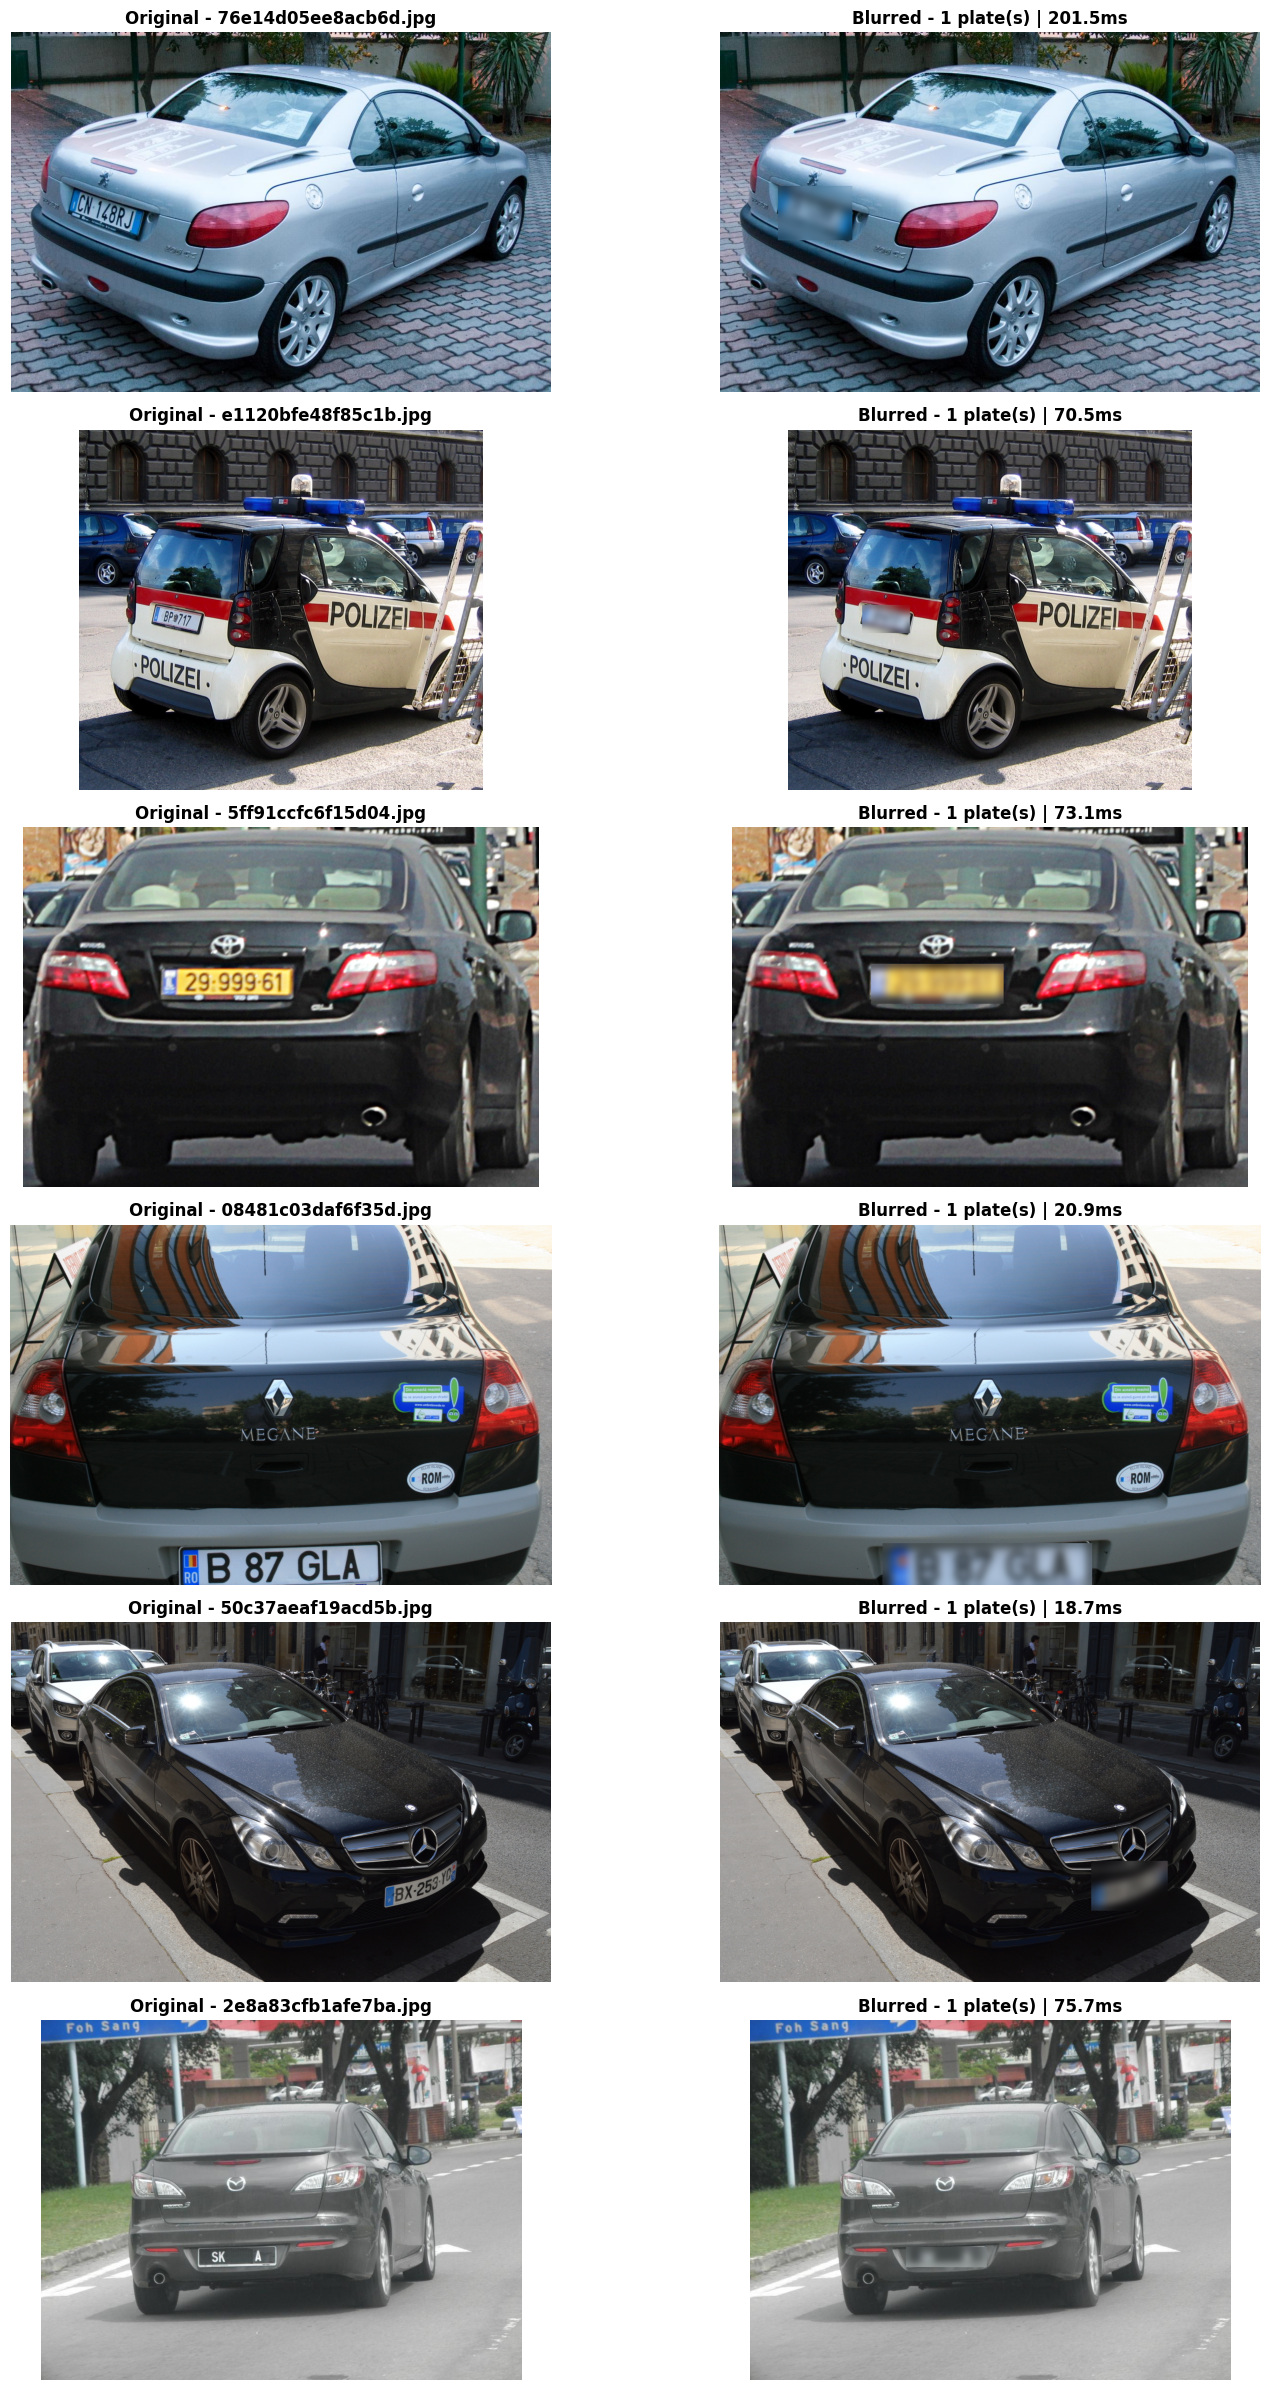


🎉 PIPELINE COMPLETE!

📁 Outputs saved to: /content/outputs/
   ├── training/weights/best.pt  - Trained model
   ├── evaluation/               - Test set evaluation results
   ├── blurred/                  - Privacy-protected images
   └── visualizations/           - Result visualizations

📊 Final Model Performance:
   mAP@50:     82.94%
   mAP@50-95:  56.57%
   Precision:  89.81%
   Recall:     78.32%
   F1-Score:   83.67%

✅ Model is ready for deployment!
   Model path: /content/outputs/training/weights/best.pt
   Use the LicensePlateBlurrer class for real-time inference

💡 NOTE: Model trained from scratch on Google Colab
   ✅ Data loaded from Google Drive
   ✅ Trained exclusively on your license plate images
   ✅ GPU acceleration used for fast training
   ✅ All knowledge comes from your dataset

📥 DOWNLOAD TRAINED MODEL:
   To download the trained model to your computer:
   1. Click folder icon on left sidebar
   2. Navigate to: /content/outputs/training/weights/
   3. Right-click '

In [ ]:
# Complete Training, Evaluation, and Real-Time Blurring Program
"""
🚀 GOOGLE COLAB VERSION - Optimized for Cloud GPU Training

This program:
1. Loads data from Google Drive (no upload needed each session)
2. Creates YOLOv8 data configuration
3. Trains model FROM SCRATCH on your dataset
4. Uses GPU acceleration (T4 GPU on Colab Free)
5. Saves trained model to Colab storage (download at end)
6. Evaluates model on test set with mAP score
7. Provides real-time license plate detection and blurring

Expected Training Time: 2-3 hours on Colab GPU (vs 9+ days on CPU)
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import yaml

print("="*80)
print("🚀 LICENSE PLATE DETECTION & BLURRING - COMPLETE PIPELINE")
print("="*80)

# ============================================================================
# STEP 1: Create Data Configuration for YOLOv8
# ============================================================================

def prepare_yolo_structure():
    """Prepare YOLOv8-compatible dataset structure by copying labels to image folders"""
    print("\n📦 Preparing YOLO dataset structure...")
    print("   Copying label files to image directories...")

    splits = [
        ('train', TRAIN_PATH, TRAIN_LABELS_PATH),
        ('val', VAL_PATH, VAL_LABELS_PATH),
        ('test', TEST_PATH, TEST_LABELS_PATH)
    ]

    for split_name, img_path, label_path in splits:
        if os.path.exists(label_path):
            label_files = list(Path(label_path).glob('*.txt'))
            copied = 0
            for label_file in label_files:
                dest = Path(img_path) / label_file.name
                if not dest.exists():
                    shutil.copy2(label_file, dest)
                    copied += 1
            print(f"   ✅ {split_name}: Copied {copied} label files")

    print("✅ YOLO structure ready!\n")

def create_data_yaml():
    """Create YAML configuration file for YOLOv8 training"""
    data_yaml_content = f"""# YOLOv8 Dataset Configuration for License Plate Detection

path: {DATASET_PATH}
train: train
val: val
test: test

# Classes
names:
  0: license_plate

nc: 1

# Dataset info
info:
  description: License Plate Detection for Privacy Blurring
  task: object_detection
  note: Labels copied from /Data/labels to image folders for YOLO compatibility
"""

    data_yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')
    with open(data_yaml_path, 'w') as f:
        f.write(data_yaml_content)

    print(f"✅ Data configuration created: {data_yaml_path}")
    return data_yaml_path


# ============================================================================
# STEP 2: Train YOLOv8 Model
# ============================================================================

def train_yolov8_model(data_yaml_path):
    """
    Train YOLOv8 model for license plate detection

    Returns:
        str: Path to best trained model
    """
    print("\n" + "="*80)
    print("📚 TRAINING YOLOV8 MODEL")
    print("="*80)

    # Train from scratch using only your local training data
    print("🎯 Training mode: From scratch (no pre-trained weights)")
    print("📁 Using training data from: /Data/train")

    # Durable checkpoint location on Drive (survives disconnects)
    DRIVE_BACKUP = '/content/drive/MyDrive/LicensePlateDetection/checkpoints'
    os.makedirs(DRIVE_BACKUP, exist_ok=True)

    # If a previous run left a checkpoint, resume from it
    local_last  = os.path.join(OUTPUT_DIR, 'training', 'weights', 'last.pt')
    drive_last  = os.path.join(DRIVE_BACKUP, 'last.pt')
    resume_from = None
    if os.path.exists(local_last):
        resume_from = local_last
    elif os.path.exists(drive_last):
        # bring the Drive checkpoint back to local so training can resume
        os.makedirs(os.path.dirname(local_last), exist_ok=True)
        shutil.copy2(drive_last, local_last)
        resume_from = local_last


    # Initialize YOLOv8 model with architecture only (no pre-trained weights)
    print(f"\n📦 Initializing YOLOv8 nano architecture...")
    if resume_from:
        print(f"🔁 Resuming from checkpoint: {resume_from}")
        model = YOLO(resume_from)
    else:
        print("📦 Initializing YOLOv8 nano architecture (fresh start)...")
        model = YOLO('yolov8n.yaml')

    print(f"✅ Model initialized with random weights")

    print(f"🎯 Training epochs: {CONFIG['epochs']}")
    print(f"📦 Batch size: {CONFIG['batch_size']}")
    print(f"🖥️  Device: {device}")
    print(f"📐 Image size: {CONFIG['input_size']}x{CONFIG['input_size']}")
    print(f"⏱️  Early stopping: {CONFIG['patience']} epochs patience")

    def _backup_to_drive(trainer):
        for name in ('last.pt', 'best.pt'):
            src = trainer.save_dir / 'weights' / name
            if src.exists():
                shutil.copy2(src, os.path.join(DRIVE_BACKUP, name))
    model.add_callback('on_fit_epoch_end', _backup_to_drive)


    # Train the model
    print(f"\n🔄 Starting training using images in {DATASET_PATH}/train...")
    print("⏳ This may take few minutes to complete...\n")

    training_results = model.train(
        data=data_yaml_path,
        epochs=CONFIG['epochs'],
        batch=CONFIG['batch_size'],
        imgsz=CONFIG['input_size'],
        cache=CONFIG['cache'],
        resume=bool(resume_from),
        device=device,
        patience=CONFIG['patience'],
        save=True,
        save_period=10,
        project=OUTPUT_DIR,
        name='training',
        exist_ok=True,
        pretrained=False,  # No pre-trained weights
        optimizer='AdamW',
        verbose=True,
        seed=42,
        deterministic=True,
        single_cls=True,
        cos_lr=True,
        close_mosaic=10,
        amp=True,
        plots=True
    )

    best_model_path = os.path.join(OUTPUT_DIR, 'training', 'weights', 'best.pt')

    print("\n" + "="*80)
    print("✅ TRAINING COMPLETE!")
    print("="*80)
    print(f"💾 Best model saved to: {best_model_path}")

    return best_model_path


# ============================================================================
# STEP 3: Evaluate Model on Test Set
# ============================================================================

def evaluate_model(model_path, data_yaml_path):
    """
    Evaluate trained model on test set and print mAP score

    Args:
        model_path: Path to trained model
        data_yaml_path: Path to data configuration

    Returns:
        dict: Evaluation metrics including mAP
    """
    print("\n" + "="*80)
    print("📊 EVALUATING MODEL ON TEST SET")
    print("="*80)

    # Load trained model
    model = YOLO(model_path)
    print(f"📦 Loaded model: {model_path}")

    # Run validation on test set
    print("\n🔍 Running validation...")

    results = model.val(
        data=data_yaml_path,
        split='test',  # Evaluate on test set
        batch=CONFIG['batch_size'],
        imgsz=CONFIG['input_size'],
        device=device,
        plots=True,
        save_json=True,
        project=OUTPUT_DIR,
        name='evaluation',
        exist_ok=True
    )

    # Extract metrics
    print("\n" + "="*80)
    print("📈 EVALUATION RESULTS (Test Set)")
    print("="*80)

    metrics = {}

    if hasattr(results, 'box'):
        box_metrics = results.box
        metrics['mAP@50'] = float(box_metrics.map50)
        metrics['mAP@50-95'] = float(box_metrics.map)
        metrics['precision'] = float(box_metrics.mp)
        metrics['recall'] = float(box_metrics.mr)

        print(f"mAP@50:        {metrics['mAP@50']:.4f} ({metrics['mAP@50']*100:.2f}%)")
        print(f"mAP@50-95:     {metrics['mAP@50-95']:.4f} ({metrics['mAP@50-95']*100:.2f}%)")
        print(f"Precision:     {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
        print(f"Recall:        {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)")

        # Calculate F1 score
        if metrics['precision'] + metrics['recall'] > 0:
            f1_score = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall'])
            metrics['f1_score'] = f1_score
            print(f"F1-Score:      {f1_score:.4f} ({f1_score*100:.2f}%)")

    print("="*80)

    return metrics


# ============================================================================
# STEP 4: Real-Time License Plate Detection & Blurring
# ============================================================================

class LicensePlateBlurrer:
    """Real-time license plate detection and blurring system"""

    def __init__(self, model_path, conf_threshold=0.5, blur_kernel=(51, 51)):
        """
        Initialize the blurrer

        Args:
            model_path: Path to trained YOLOv8 model
            conf_threshold: Confidence threshold for detections
            blur_kernel: Gaussian blur kernel size (must be odd)
        """
        self.model = YOLO(model_path)
        self.conf_threshold = conf_threshold
        self.blur_kernel = blur_kernel
        self.device = device

        print(f"✅ Blurrer initialized with model: {os.path.basename(model_path)}")
        print(f"   Confidence threshold: {conf_threshold}")
        print(f"   Blur kernel: {blur_kernel}")

    def detect_and_blur(self, image):
        """
        Detect license plates and blur them

        Args:
            image: Input image (BGR format)

        Returns:
            tuple: (blurred_image, num_detections, inference_time_ms)
        """
        start_time = time.time()

        # Run inference
        results = self.model.predict(
            source=image,
            conf=self.conf_threshold,
            device=self.device,
            verbose=False
        )[0]

        # Create copy for blurring
        blurred_img = image.copy()
        num_detections = 0

        # Process detections
        if results.boxes is not None:
            for box in results.boxes:
                # Get coordinates
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                confidence = float(box.conf[0].cpu().numpy())

                if confidence >= self.conf_threshold:
                    # Ensure coordinates are within bounds
                    h, w = blurred_img.shape[:2]
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w, x2), min(h, y2)

                    # Extract ROI and apply blur
                    roi = blurred_img[y1:y2, x1:x2]
                    if roi.size > 0:
                        blurred_roi = cv2.GaussianBlur(roi, self.blur_kernel, 0)
                        blurred_img[y1:y2, x1:x2] = blurred_roi
                        num_detections += 1

        # Calculate inference time
        inference_time = (time.time() - start_time) * 1000  # ms

        return blurred_img, num_detections, inference_time


def test_real_time_blurring(blurrer, test_images, num_samples=6):
    """
    Test real-time blurring on sample images

    Args:
        blurrer: LicensePlateBlurrer instance
        test_images: List of test image paths
        num_samples: Number of samples to display
    """
    print("\n" + "="*80)
    print("🎬 TESTING REAL-TIME BLURRING")
    print("="*80)

    samples = test_images[:num_samples]
    inference_times = []
    total_detections = 0

    fig, axes = plt.subplots(num_samples, 2, figsize=(16, num_samples * 4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for idx, img_path in enumerate(samples):
        # Read image
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Detect and blur
        blurred, num_det, inf_time = blurrer.detect_and_blur(img)
        blurred_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

        # Save blurred image
        output_path = os.path.join(OUTPUT_DIR, 'blurred', img_path.name)
        cv2.imwrite(output_path, blurred)

        inference_times.append(inf_time)
        total_detections += num_det

        # Display
        axes[idx, 0].imshow(original)
        axes[idx, 0].set_title(f'Original - {img_path.name}', fontsize=12, fontweight='bold')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(blurred_rgb)
        axes[idx, 1].set_title(f'Blurred - {num_det} plate(s) | {inf_time:.1f}ms',
                               fontsize=12, fontweight='bold')
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'visualizations', 'blurring_results.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# MAIN EXECUTION PIPELINE
# ============================================================================

print("\n" + "="*80)
print("🔄 STARTING COMPLETE PIPELINE")
print("="*80)

print("\n💡 TRAINING APPROACH: From Scratch on Google Colab")
print("="*80)
print("✅ Images from /Data/train, /Data/val, /Data/test")
print("✅ Labels from /Data/labels/train, /Data/labels/val, /Data/labels/test")
print("="*80)

# Step 1: Prepare YOLO-compatible structure
print("\n[1/6] Preparing YOLO dataset structure...")
prepare_yolo_structure()

# Step 2: Create data configuration
print("\n[2/6] Creating data configuration...")
data_yaml_path = create_data_yaml()

# Step 3: Train model
print("\n[3/6] Training YOLOv8 model from scratch...")
best_model_path = train_yolov8_model(data_yaml_path)

# Step 4: Evaluate model on test set
print("\n[4/6] Evaluating model on test set...")
evaluation_metrics = evaluate_model(best_model_path, data_yaml_path)

# Step 5: Initialize real-time blurrer
print("\n[5/6] Initializing real-time blurrer...")
blurrer = LicensePlateBlurrer(
    model_path=best_model_path,
    conf_threshold=CONFIG['conf_threshold'],
    blur_kernel=CONFIG['blur_kernel']
)

# Step 6: Test real-time blurring
print("\n[6/6] Testing real-time blurring on test images...")
test_images = list(Path(TEST_PATH).glob('*.jpg')) + list(Path(TEST_PATH).glob('*.png'))

if len(test_images) > 0:
    test_real_time_blurring(blurrer, test_images, num_samples=min(6, len(test_images)))
else:
    print("⚠️  No test images found in TEST_PATH")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("🎉 PIPELINE COMPLETE!")
print("="*80)
print(f"\n📁 Outputs saved to: {OUTPUT_DIR}/")
print(f"   ├── training/weights/best.pt  - Trained model")
print(f"   ├── evaluation/               - Test set evaluation results")
print(f"   ├── blurred/                  - Privacy-protected images")
print(f"   └── visualizations/           - Result visualizations")

print(f"\n📊 Final Model Performance:")
if evaluation_metrics:
    print(f"   mAP@50:     {evaluation_metrics.get('mAP@50', 0)*100:.2f}%")
    print(f"   mAP@50-95:  {evaluation_metrics.get('mAP@50-95', 0)*100:.2f}%")
    print(f"   Precision:  {evaluation_metrics.get('precision', 0)*100:.2f}%")
    print(f"   Recall:     {evaluation_metrics.get('recall', 0)*100:.2f}%")
    if 'f1_score' in evaluation_metrics:
        print(f"   F1-Score:   {evaluation_metrics.get('f1_score', 0)*100:.2f}%")

print(f"\n✅ Model is ready for deployment!")
print(f"   Model path: {best_model_path}")
print(f"   Use the LicensePlateBlurrer class for real-time inference")

print("\n💡 NOTE: Model trained from scratch on Google Colab")
print("   ✅ Data loaded from Google Drive")
print("   ✅ Trained exclusively on your license plate images")
print("   ✅ GPU acceleration used for fast training")
print("   ✅ All knowledge comes from your dataset")

print("\n📥 DOWNLOAD TRAINED MODEL:")
print("   To download the trained model to your computer:")
print("   1. Click folder icon on left sidebar")
print(f"   2. Navigate to: {OUTPUT_DIR}/training/weights/")
print("   3. Right-click 'best.pt' → Download")
print("   4. Or use: from google.colab import files")
print(f"             files.download('{best_model_path}')")

print("\n" + "="*80)


Test some more realtime blurring of images
--

Testing few more real-time blurring on test images...

🎬 TESTING REAL-TIME BLURRING


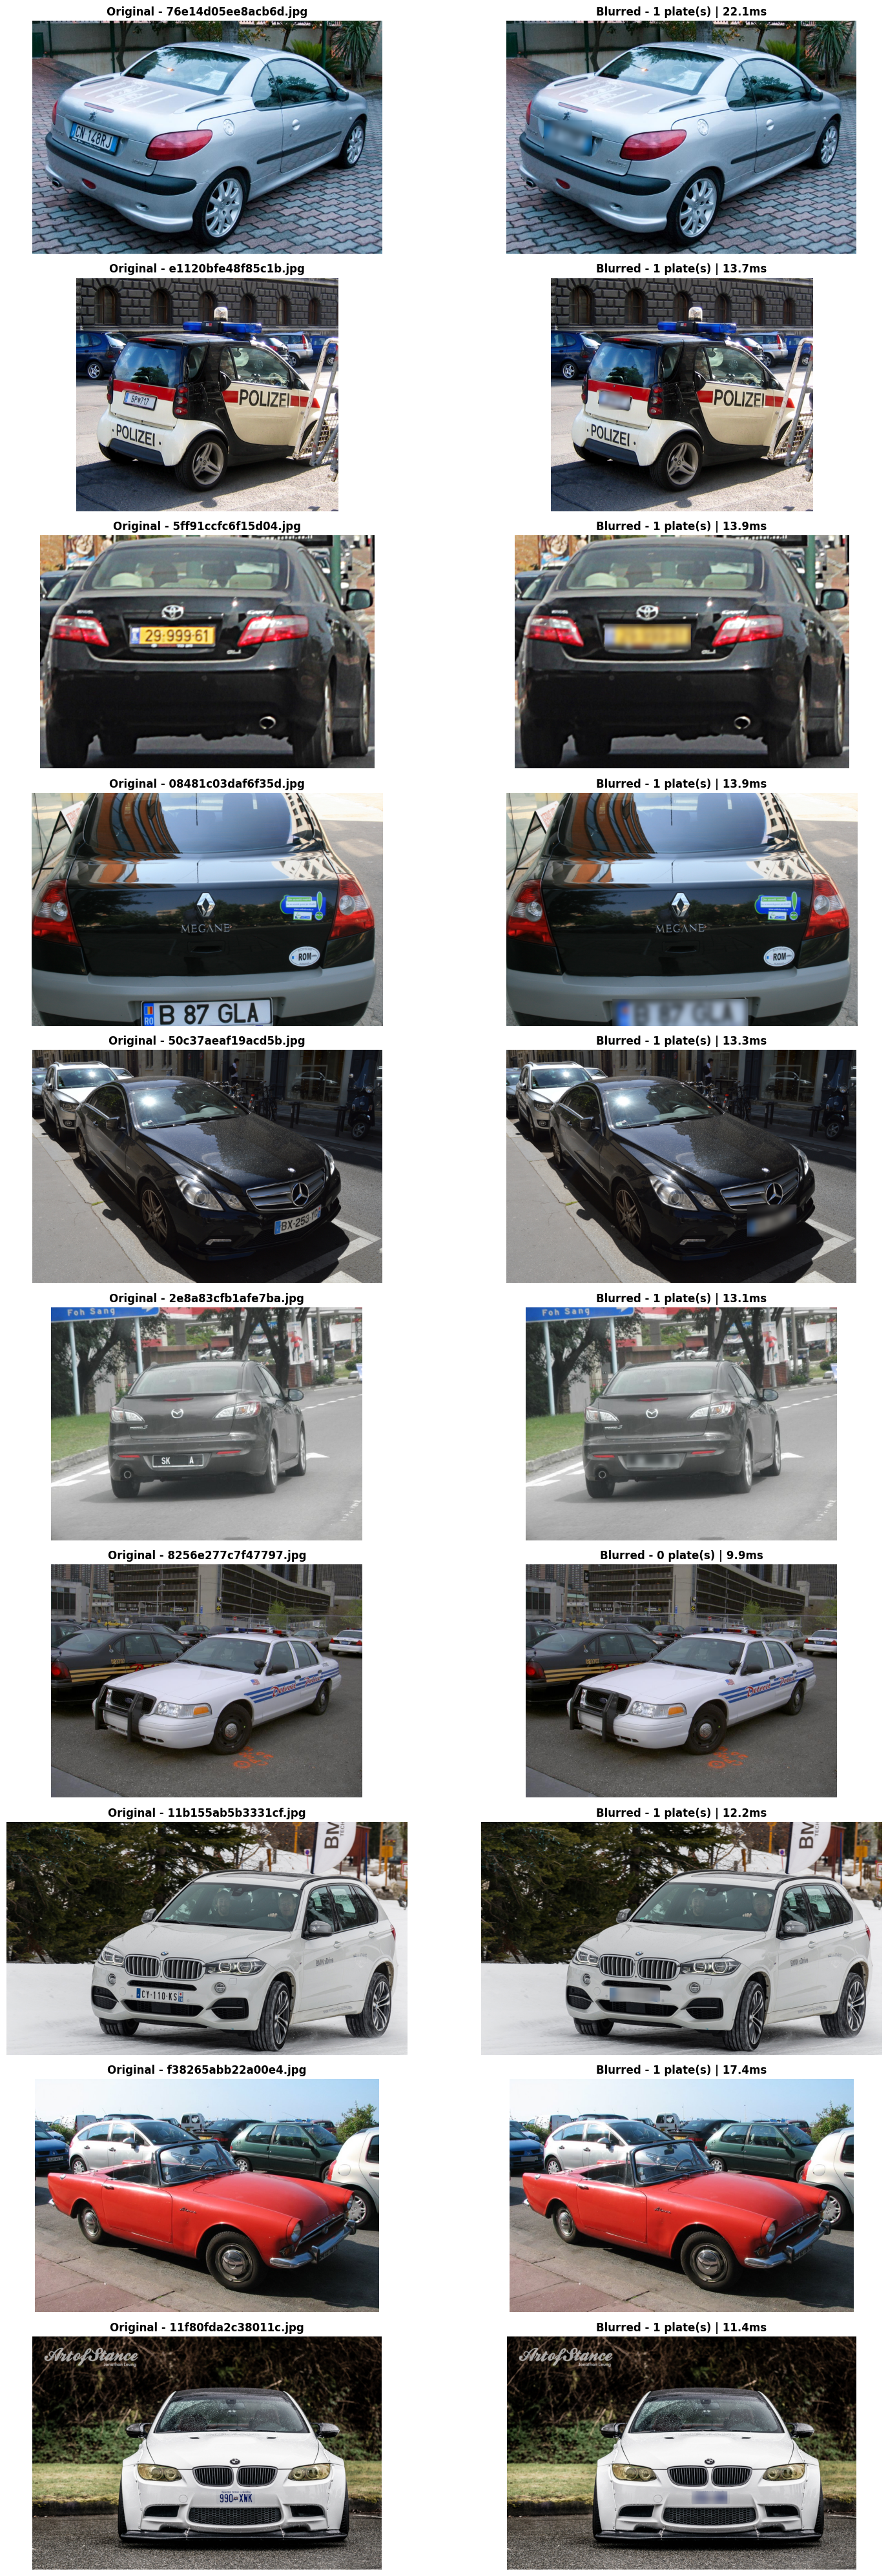

In [ ]:
# Test real-time blurring
print("Testing few more real-time blurring on test images...")
test_images = list(Path(TEST_PATH).glob('*.jpg')) + list(Path(TEST_PATH).glob('*.png'))
test_real_time_blurring(blurrer, test_images, num_samples=10)

# Business questions


Question 1
--


How do you convert normalized YOLO bounding box coordinates (center_x, center_y, width, height) into pixel coordinates suitable for drawing rectangles with OpenCV?

YOLO gives you a box as four fractions (0–1): the center x/y and the width/height. OpenCV's cv2.rectangle wants two corners in whole pixels. So:

1. Scale to pixels: multiply x and width by image width, y and height by image height.
2. Center → corners: top-left = center minus half the size, bottom-right = center plus half the size.

```
x1 = (cx - w/2) * img_w
y1 = (cy - h/2) * img_h
x2 = (cx + w/2) * img_w
y2 = (cy + h/2) * img_h
```
3. Wrap them in int(...) and draw: cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness).



Question 2
--

Write a function to overlay bounding boxes onto raw images. Why is this step critical before starting the training process?


In [1]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

def overlay_boxes(image_path, label_path, class_names=('license_plate',), show=True):
    """Draw YOLO-format bounding boxes from a label file onto its image."""
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"⚠️  Could not read image: {image_path}")
        return None
    img_h, img_w = img.shape[:2]

    label_path = Path(label_path)
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.split()
                if len(parts) != 5:
                    continue  # skip malformed lines
                cls, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])

                # normalized center+size -> pixel corners
                x1 = int((cx - w / 2) * img_w)
                y1 = int((cy - h / 2) * img_h)
                x2 = int((cx + w / 2) * img_w)
                y2 = int((cy + h / 2) * img_h)

                # clamp to image bounds
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_w - 1, x2), min(img_h - 1, y2)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                label = class_names[cls] if cls < len(class_names) else str(cls)
                cv2.putText(img, label, (x1, max(0, y1 - 5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    if show:
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # OpenCV is BGR; matplotlib is RGB
        plt.axis('off')
        plt.title(Path(image_path).name)
        plt.show()

    return img


The model learns exactly what your labels say — so if the labels are wrong, training faithfully learns the wrong thing, and you won't discover it until hours of GPU time later. Overlaying the boxes is the fastest way to catch problems that are invisible in the raw numbers:

Question 3
--

How did annotation quality impact the final blurring accuracy?

Annotation quality matters here more than in a typical detector, because in the pipeline the blur is applied directly to whatever box the model predicts — there's no human in the loop. The model can only learn to place boxes as well as the boxes it was trained on, so any label defect propagates straight through to the blurred output. The main effects:

Missing labels → missed plates → privacy leaks.

Question 4
--

How did you preprocess images before feeding them into YOLOv8 without losing fine-grained plate details?

Two things matter for keeping plate details sharp:

1. Letterbox resize (not stretching). YOLO shrinks the image to the target size but keeps its shape, padding the edges with gray instead of squashing it into a square. This stops the plate characters from getting distorted.

2. Input size (imgsz). This is where detail is actually lost or kept. Plates are small, so the more you shrink the image, the more fine detail disappears. We used 480 for speed — good enough to find plates, but bumping it back to 640 keeps more detail if small/faraway plates get missed.

A couple of automatic extras: pixels are scaled to 0–1 (no detail lost), and training augmentations like mosaic are turned off near the end (close_mosaic) and never used at inference — so the images that are blurred are clean and undistorted.

Feed it the original full-quality images, so the only shrink that ever happens is YOLO's resize.

Question 5
--

Why did you choose YOLOv8 for license plate detection instead of a two-stage detector?

YOLOv8 is a one-stage detector — it predicts boxes and classes in a single pass — while two-stage detectors (like Faster R-CNN) first propose regions, then classify them. For this project one-stage wins on the things that matter:

 - Speed / real-time. The goal is real-time blurring of video streams. YOLOv8 runs in a single pass, so it's far faster than two-stage models — essential for keeping up with a live feed.
 - The task is simple. One class (license_plate), high-contrast, well-defined objects. You don't need the extra localization precision of a two-stage detector; YOLOv8 is more than accurate enough.
 - Efficient on limited hardware. The nano model trains and runs fast on a free Colab T4 — a two-stage detector would be heavier and slower to train.
 - Easy to use. Ultralytics handles preprocessing, training, augmentation, and export out of the box, so the pipeline is simple to build and maintain.
 
In short: two-stage detectors trade speed for a bit more accuracy — but here speed is the priority and the detection task is easy, so YOLOv8 gives you real-time performance with accuracy that's more than good enough.



Question 6
--

Which YOLOv8 variant did you select, and how did it balance speed and accuracy for this use case?

We used YOLOv8n (nano) — the smallest and fastest variant in the family (n → s → m → l → x, growing in size and accuracy).

How it balances speed and accuracy for this use case:

- Speed: Fewest parameters, so the fastest inference — which is what real-time video blurring needs — and quick to train on a free Colab T4.
- Accuracy is enough: The task is easy (one class, large high-contrast plates), so the bigger variants' extra accuracy would be wasted. Nano detects plates reliably without it.
- Fits the hardware: Light enough to train and run within Colab's free GPU limits, unlike the heavier m/l/x models.

Question 7
--

How did license plate characteristics influence your choice of model scale?

License plates are an easy detection target, and that's exactly why the small nano scale was enough:

 - Single, consistent object class. Just "license_plate" — no variety of shapes or categories to distinguish, so the model doesn't need the extra capacity of a larger scale.
 - High contrast, well-defined shape. Plates are bright, rectangular, and stand out from the background — easy features to learn, so a small model detects them reliably.
 - Detection, not reading. You only need to locate and blur the plate, not recognize the characters. Locating a clear rectangle is a simple job; a bigger model's precision would be wasted.

Question 8
--

How did you apply blurring only within the detected bounding box?

The trick is to blur only a cropped slice of the image, not the whole thing. For each detected box:

 - Get pixel corners from the detection (box.xyxy gives x1, y1, x2, y2 in pixels), and clamp them to the image bounds.
 - Cut out just that region using NumPy slicing: roi = image[y1:y2, x1:x2].
 - Blur only that patch: blurred_roi = cv2.GaussianBlur(roi, (51, 51), 0).
 - Paste it back in place: image[y1:y2, x1:x2] = blurred_roi.